<a href="https://colab.research.google.com/github/osiriswhisper/first_repository/blob/kaggle_competitons/spaceship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
test_filepath= '/content/test.csv'
train_filepath='/content/train.csv'

In [5]:
df=pd.read_csv(train_filepath)
test_df=pd.read_csv(test_filepath)

In [21]:
test_df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,0.0,1.0,G/3/S,TRAPPIST-1e,27.0,0.0,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,0.0,0.0,F/4/S,TRAPPIST-1e,19.0,0.0,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,1.0,1.0,C/0/S,55 Cancri e,31.0,0.0,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,1.0,0.0,C/1/S,TRAPPIST-1e,38.0,0.0,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,0.0,0.0,F/5/S,TRAPPIST-1e,20.0,0.0,10.0,0.0,635.0,0.0,0.0,Brence Harperez


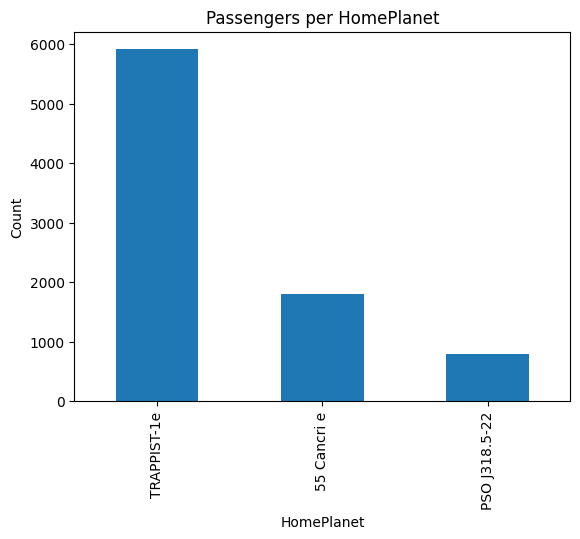

In [27]:
df['Destination'].value_counts().plot(kind='bar')
plt.title('Passengers per HomePlanet')
plt.xlabel('HomePlanet')
plt.ylabel('Count')
plt.show()


In [16]:
df['HomePlanet'] = df['HomePlanet'].map({'Earth': 0, 'Europa': 1,'Mars':2})
test_df['HomePlanet'] = test_df['HomePlanet'].map({'Earth': 0, 'Europa': 1,'Mars':2})

In [17]:
df['VIP']=df['VIP'].map({True:1,False:0})
test_df['VIP']=test_df['VIP'].map({True:1,False:0})

In [18]:
df['CryoSleep']=df['CryoSleep'].map({True:1,False:0})
test_df['CryoSleep']=test_df['CryoSleep'].map({True:1,False:0})

In [28]:
df['Destination']=df['Destination'].map({'TRAPPIST-1e':0,'55 Cancri e':1,'PSO J318.5-22':2})
test_df['Destination']=test_df['Destination'].map({'TRAPPIST-1e':0,'55 Cancri e':1,'PSO J318.5-22':2})

In [25]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
df['Age'] = imputer.fit_transform(df[['Age']])
test_df['Age'] = imputer.fit_transform(test_df[['Age']])

In [29]:
df['Destination']=df['Destination'].fillna(df['Destination'].mode()[0])
test_df['Destination']=test_df['Destination'].fillna(test_df['Destination'].mode()[0])

In [30]:
df['CryoSleep']=df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])
test_df['CryoSleep']=test_df['CryoSleep'].fillna(test_df['CryoSleep'].mode()[0])

In [31]:
df['VIP']=df['VIP'].fillna(df['VIP'].mode()[0])
test_df['VIP']=test_df['VIP'].fillna(test_df['VIP'].mode()[0])

In [33]:
df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0] if not df['HomePlanet'].mode().empty else -1)
test_df['HomePlanet'] = test_df['HomePlanet'].fillna(test_df['HomePlanet'].mode()[0] if not test_df['HomePlanet'].mode().empty else -1)

In [35]:
features=['HomePlanet','CryoSleep','Destination','Age','VIP']
x=df[features]
y=df['Transported']
x_test_final=test_df[features]

In [36]:
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=42)

In [37]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [38]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_val)
accuracy=accuracy_score(y_val,y_pred)


In [42]:
print(accuracy)

0.7251293847038528


In [43]:
final_predictions=model.predict(x_test_final)

In [44]:
submission_df=pd.DataFrame({'PassengerId':test_df['PassengerId'],'Transported':final_predictions})
submission_df['Transported']=submission_df['Transported'].map({1:True,0:False})

In [45]:
submission_df.to_csv('spacetitan.csv',index=False)

In [46]:
from google.colab import files
files.download('spacetitan.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>